# POUNCE from CasADi

[CasADi](https://web.casadi.org/) is a symbolic framework for nonlinear
optimization and algorithmic differentiation. POUNCE registers with it as an
`nlpsol` **plugin**, so a CasADi model hands its problem to POUNCE exactly the
way it would hand it to Ipopt:

```python
solver = ca.nlpsol("solver", "pounce", nlp, {"pounce": {"tol": 1e-9}})
```

Because it is a genuine plugin and not a Python-side wrapper, everything
CasADi layers on top of a solver keeps working: `Opti`, MX graphs, parameters,
embedding a solve inside another `Function`, and differentiating through the
solve.

**Setup.** The plugin is a small C++ shared library built against the CasADi
you have installed — there is no wheel yet:

```sh
pip install casadi
git clone https://github.com/jkitchin/pounce && cd pounce
cargo build --release -p pounce-cinterface
cd casadi && make fetch-src && make && make install
```

`make install` drops the plugin into CasADi's own package directory, which its
loader searches first, so nothing else is needed. If you skipped that step, set
`CASADIPATH` to the repository's `casadi/` directory before starting Jupyter.
Full details: [`docs/src/casadi.md`](../../docs/src/casadi.md).

In [1]:
import time

import casadi as ca
import numpy as np

# Fail early and clearly if the plugin is not on CasADi's search path.
_probe = ca.MX.sym("probe")
try:
    ca.nlpsol("probe", "pounce", {"x": _probe, "f": _probe**2})
except RuntimeError as exc:
    raise SystemExit(
        "The POUNCE plugin is not loadable. Build and install it with\n"
        "  cd casadi && make fetch-src && make && make install\n"
        "or set CASADIPATH to the repository's casadi/ directory.\n\n"
        f"{exc}"
    ) from None

print("casadi", ca.__version__, "— pounce plugin loaded")

casadi 3.7.2 — pounce plugin loaded


## 1. A first solve

Rosenbrock inside a circle of radius $\sqrt{p}$, with $p$ a **parameter** —
one solver object, re-callable at any $p$:

$$\min_x \; (1-x_0)^2 + 100(x_1 - x_0^2)^2 \quad\text{s.t.}\quad x_0^2 + x_1^2 \le p$$

Options for the solver itself go in the `pounce` dict and use
Ipopt-compatible names, so an `ipopt.opt` you already have translates
directly.

In [2]:
x = ca.MX.sym("x", 2)
p = ca.MX.sym("p")

nlp = {
    "x": x,
    "p": p,
    "f": (1 - x[0]) ** 2 + 100 * (x[1] - x[0] ** 2) ** 2,
    "g": x[0] ** 2 + x[1] ** 2 - p,
}

solver = ca.nlpsol("solver", "pounce", nlp, {
    "print_time": False,
    "pounce": {"print_level": 0, "tol": 1e-9},
})

sol = solver(x0=[0.5, 0.5], p=1.5, lbg=-ca.inf, ubg=0)

print("x*    ", sol["x"].full().ravel())
print("f(x*) ", float(sol["f"]))
print("lam_g ", sol["lam_g"].full().ravel())
print("lam_x ", sol["lam_x"].full().ravel())

x*     [0.90723396 0.82275546]
f(x*)  0.008615650364308444
lam_g  [0.03865095]
lam_x  [0. 0.]


### Statistics

`stats()` carries CasADi's usual keys plus POUNCE's full per-iteration trace —
the same columns its iteration table prints, so a convergence plot needs no
stdout parsing.

In [3]:
st = solver.stats()
print("success      ", st["success"])
print("return_status", st["return_status"])
print("iterations   ", st["iter_count"])
print("trace keys   ", sorted(st["iterations"]))

success       True
return_status Solve_Succeeded
iterations    13
trace keys    ['alpha_du', 'alpha_pr', 'd_norm', 'inf_du', 'inf_pr', 'ls_trials', 'mu', 'obj', 'regularization_size']


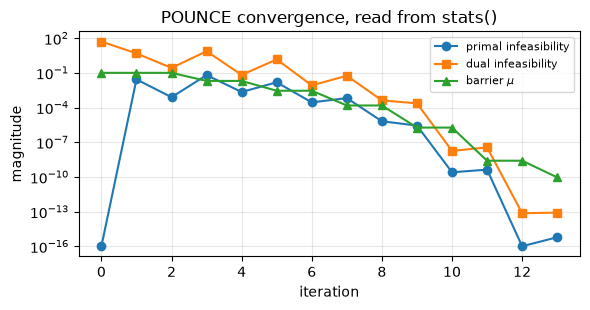

In [4]:
import matplotlib.pyplot as plt

it = st["iterations"]
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.semilogy(np.maximum(it["inf_pr"], 1e-16), "o-", label="primal infeasibility")
ax.semilogy(np.maximum(it["inf_du"], 1e-16), "s-", label="dual infeasibility")
ax.semilogy(np.maximum(it["mu"], 1e-16), "^-", label=r"barrier $\mu$")
ax.set_xlabel("iteration")
ax.set_ylabel("magnitude")
ax.set_title("POUNCE convergence, read from stats()")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()

## 2. `Opti`

`Opti` is CasADi's modelling front end, and it accepts an `nlpsol` **plugin
name** — which is exactly what POUNCE registers. A minimum-effort rocket
ascent, 40 control intervals:

Solve_Succeeded in 5 iterations
control effort 11.200750469043149


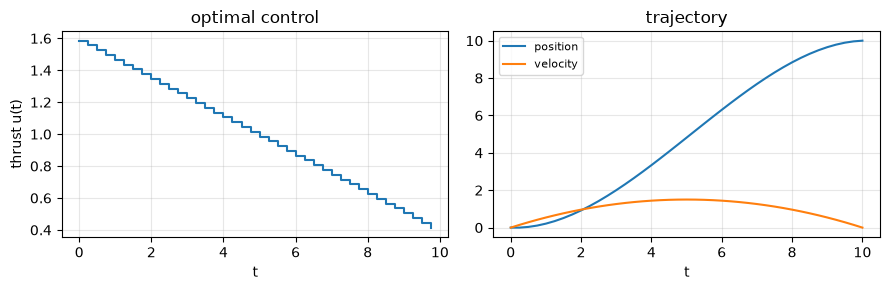

In [5]:
N, T, u_max = 40, 10.0, 3.0
dt = T / N

opti = ca.Opti()
pos, vel, u = opti.variable(N + 1), opti.variable(N + 1), opti.variable(N)

for k in range(N):  # explicit Euler: ṗ = v, v̇ = u − g
    opti.subject_to(pos[k + 1] == pos[k] + dt * vel[k])
    opti.subject_to(vel[k + 1] == vel[k] + dt * (u[k] - 1.0))

opti.subject_to(opti.bounded(0, u, u_max))
opti.subject_to(pos[0] == 0)
opti.subject_to(vel[0] == 0)
opti.subject_to(pos[N] == 10)
opti.subject_to(vel[N] == 0)
opti.minimize(dt * ca.sumsqr(u))
opti.set_initial(u, 1.0)

opti.solver("pounce", {"print_time": False}, {"print_level": 0, "tol": 1e-8})
ocp = opti.solve()

print(ocp.stats()["return_status"], "in", ocp.stats()["iter_count"], "iterations")
print("control effort", float(ocp.value(dt * ca.sumsqr(u))))

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].step(np.arange(N) * dt, ocp.value(u), where="post")
ax[0].set(xlabel="t", ylabel="thrust u(t)", title="optimal control")
ax[1].plot(np.arange(N + 1) * dt, ocp.value(pos), label="position")
ax[1].plot(np.arange(N + 1) * dt, ocp.value(vel), label="velocity")
ax[1].set(xlabel="t", title="trajectory")
ax[1].legend(fontsize=8)
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()

## 3. Warm starting a receding-horizon loop

Build the solver once, call it per step with a new parameter value and the
previous solution. Two options make the multipliers you pass actually count —
without them they are outputs only, which is Ipopt's contract too:

```python
"warm_start_init_point": "yes",
"mu_init": 1e-6,
```

In [6]:
Nh, dth = 20, 0.1
X = ca.MX.sym("X", 2, Nh + 1)
U = ca.MX.sym("U", 1, Nh)
x0_par = ca.MX.sym("x0_par", 2)

cost, cons = 0, [X[:, 0] - x0_par]
for k in range(Nh):
    nxt = ca.vertcat(
        X[0, k] + dth * X[1, k],
        X[1, k] + dth * (U[0, k] - 0.1 * X[1, k] * ca.fabs(X[1, k])),
    )
    cons.append(X[:, k + 1] - nxt)
    cost += X[0, k] ** 2 + 0.1 * X[1, k] ** 2 + 0.01 * U[0, k] ** 2
cost += 10 * (X[0, Nh] ** 2 + X[1, Nh] ** 2)

mpc_nlp = {"x": ca.vertcat(ca.vec(X), ca.vec(U)), "p": x0_par,
           "f": cost, "g": ca.vertcat(*cons)}
nx = 2 * (Nh + 1) + Nh

cold = ca.nlpsol("cold", "pounce", mpc_nlp,
                 {"print_time": False, "pounce": {"print_level": 0, "tol": 1e-8}})
warm = ca.nlpsol("warm", "pounce", mpc_nlp, {"print_time": False, "pounce": {
    "print_level": 0, "tol": 1e-8,
    "warm_start_init_point": "yes", "mu_init": 1e-6}})

bounds = dict(lbg=0, ubg=0,
              lbx=[-ca.inf] * (2 * (Nh + 1)) + [-2.0] * Nh,
              ubx=[ca.inf] * (2 * (Nh + 1)) + [2.0] * Nh)

state, prev = ca.DM([1.0, 0.0]), None
cold_iters, warm_iters = [], []
for step in range(8):
    args = dict(p=state, **bounds)
    cold(x0=ca.DM.zeros(nx), **args)          # reference: what a cold solve costs
    cold_iters.append(cold.stats()["iter_count"])

    if prev is None:
        prev = cold(x0=ca.DM.zeros(nx), **args)
    else:
        prev = warm(x0=prev["x"], lam_g0=prev["lam_g"], lam_x0=prev["lam_x"], **args)
        warm_iters.append(warm.stats()["iter_count"])

    u0 = float(prev["x"][2 * (Nh + 1)])
    pos_, vel_ = float(state[0]), float(state[1])
    state = ca.DM([pos_ + dth * vel_, vel_ + dth * (u0 - 0.1 * vel_ * abs(vel_))])

print("cold:", cold_iters, f"(mean {np.mean(cold_iters):.1f})")
print("warm:", warm_iters, f"(mean {np.mean(warm_iters):.1f})")

cold: [9, 9, 8, 8, 8, 8, 8, 7] (mean 8.1)
warm: [8, 8, 8, 7, 7, 4, 4] (mean 6.6)


## 4. Differentiating through the solve

An `nlpsol` object is a CasADi `Function`, so it composes into bigger graphs
and can be differentiated: CasADi's `Nlpsol` base class builds forward and
adjoint derivatives of the solution map by linearizing the KKT system at the
returned point, and every plugin inherits that. The result is exact (implicit
function theorem), not a finite difference — but it is only as good as the
multipliers, so tighten `tol` if sensitivities look off.

In [7]:
xs = ca.MX.sym("x", 2)
ps = ca.MX.sym("p", 2)

# min (x0-p0)^2 + (x1-p1)^2  s.t.  ||x|| <= 1
proj = ca.nlpsol("proj", "pounce", {
    "x": xs, "p": ps,
    "f": (xs[0] - ps[0]) ** 2 + (xs[1] - ps[1]) ** 2,
    "g": xs[0] ** 2 + xs[1] ** 2 - 1,
}, {"print_time": False, "pounce": {"print_level": 0, "tol": 1e-12}})

r = proj(x0=[0.1, 0.1], p=ps, lbg=-ca.inf, ubg=0)
x_of_p = ca.Function("x_of_p", [ps], [r["x"]])
dx_dp = ca.Function("dx_dp", [ps], [ca.jacobian(r["x"], ps)])

p_val = ca.DM([2.0, 1.0])
eps = 1e-6
fd = ca.DM.zeros(2, 2)
for j in range(2):
    d = ca.DM.zeros(2)
    d[j] = eps
    fd[:, j] = (x_of_p(p_val + d) - x_of_p(p_val - d)) / (2 * eps)

print("x*(p)          ", x_of_p(p_val).full().ravel())
print("dx*/dp         ", dx_dp(p_val).full().tolist())
print("central diff   ", fd.full().tolist())
print("max difference ", float(ca.norm_inf(dx_dp(p_val) - fd)))

x*(p)           [0.8944272 0.4472136]
dx*/dp          [[0.0894427195468434, -0.17888543909368673], [-0.17888543909368676, 0.3577708781873735]]
central diff    [[0.08944271956412564, -0.17888543912825128], [-0.17888543907274013, 0.35777087817323583]]
max difference  3.456454567007938e-11


Because the solve is differentiable, it can sit *inside* another
optimization — a bilevel problem in four lines: choose the parameter $p$ so
that the inner solution lands on a target.

In [8]:
target = ca.DM([0.6, 0.8])
q = ca.MX.sym("q", 2)
inner = proj(x0=[0.1, 0.1], p=q, lbg=-ca.inf, ubg=0)["x"]

outer = ca.nlpsol("outer", "pounce", {"x": q, "f": ca.sumsqr(inner - target)},
                  {"print_time": False, "pounce": {"print_level": 0}})
best = outer(x0=[2.0, 1.0])

print("p*        ", best["x"].full().ravel())
print("x*(p*)    ", x_of_p(best["x"]).full().ravel())
print("target    ", target.full().ravel())

p*         [1.19063476 1.58751302]
x*(p*)     [0.6 0.8]
target     [0.6 0.8]


## 5. Feedback gains, and a trap worth knowing about

The derivative above was of an *unbounded* variable. Take the same idea to an
NMPC problem — differentiate the first control move with respect to the measured
state, i.e. the feedback gain — and the control is bounded, which is where
CasADi's solution-map derivative has a sharp edge.

An interior-point method drives the multipliers of untouched bounds toward zero
but never reaches it; POUNCE leaves ~1e-12 on them, Ipopt ~1e-13. CasADi's
derivative reads *any* nonzero bound multiplier as an active constraint and
fixes that variable, so one residual 1e-12 zeroes the entire sensitivity row.
Every bounded variable in the model is affected, silently.

The plugin therefore clips demonstrably inactive multipliers to zero by default
(`clip_inactive_lam`, on primal distance to the bound, the same rule and option
name CasADi's ipopt plugin offers — but that one defaults it **off**). Below,
the analytic gain is checked against a re-solve, which cannot be fooled the same
way.

In [9]:
Nh_g, dt_g = 20, 0.05
Xg, Ug = ca.MX.sym("X", 2, Nh_g + 1), ca.MX.sym("U", 1, Nh_g)
x0g = ca.MX.sym("x0g", 2)
cost_g, cons_g = 0, [Xg[:, 0] - x0g]
for k in range(Nh_g):
    cons_g.append(Xg[:, k + 1] - ca.vertcat(
        Xg[0, k] + dt_g * Xg[1, k],
        Xg[1, k] + dt_g * (Ug[0, k] - 0.1 * Xg[1, k] * ca.fabs(Xg[1, k]))))
    cost_g += Xg[0, k]**2 + 0.1 * Xg[1, k]**2 + 0.01 * Ug[0, k]**2
cost_g += 10 * (Xg[0, Nh_g]**2 + Xg[1, Nh_g]**2)

gain_nlp = {"x": ca.vertcat(ca.vec(Xg), ca.vec(Ug)), "p": x0g,
            "f": cost_g, "g": ca.vertcat(*cons_g)}
nxg, iu0 = 2 * (Nh_g + 1) + Nh_g, 2 * (Nh_g + 1)
gargs = dict(lbg=0, ubg=0,
             lbx=[-ca.inf] * (2 * (Nh_g + 1)) + [-2.0] * Nh_g,   # bounded controls
             ubx=[ca.inf] * (2 * (Nh_g + 1)) + [2.0] * Nh_g)
p0, eps = ca.DM([0.05, 0.0]), 1e-4

def gain(plugin, extra={}):
    key = "pounce" if plugin == "pounce" else "ipopt"
    opts = {"print_time": False, key: {"print_level": 0, "tol": 1e-11}}
    opts.update(extra)
    S = ca.nlpsol("S", plugin, gain_nlp, opts)
    ps = ca.MX.sym("p", 2)
    sol = S(x0=ca.DM.zeros(nxg), p=ps, **gargs)
    analytic = float(ca.Function("J", [ps], [ca.jacobian(sol["x"][iu0], ps)])(p0)[0])
    u = lambda pv: float(S(x0=ca.DM.zeros(nxg), p=pv, **gargs)["x"][iu0])
    truth = (u(p0 + ca.DM([eps, 0])) - u(p0 - ca.DM([eps, 0]))) / (2 * eps)
    return analytic, truth

for label, plugin, extra in [
    ("pounce (default)", "pounce", {}),
    ("pounce, clipping off", "pounce", {"clip_inactive_lam": False}),
    ("ipopt (default)", "ipopt", {}),
    ("ipopt, clip_inactive_lam", "ipopt", {"clip_inactive_lam": True}),
]:
    a, t = gain(plugin, extra)
    verdict = "correct" if abs(a - t) < 1e-3 * max(1.0, abs(t)) else "SILENTLY ZERO"
    print(f"{label:26s} analytic du0/dx0 = {a:+10.6f}   re-solve = {t:+10.6f}   {verdict}")

pounce (default)           analytic du0/dx0 =  -9.109838   re-solve =  -9.109838   correct


pounce, clipping off       analytic du0/dx0 =  -0.000000   re-solve =  -9.109838   SILENTLY ZERO



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

ipopt (default)            analytic du0/dx0 =  -0.000000   re-solve =  -9.109838   SILENTLY ZERO
ipopt, clip_inactive_lam   analytic du0/dx0 =  -9.109838   re-solve =  -9.109838   correct


## 6. Limited-memory Hessians over the nonlinear variables

Many models are mostly linear — slacks, balances, flows with constant
coefficients. Under `hessian_approximation=limited-memory` the L-BFGS update
spans every variable by default, spending storage and curvature information on
variables whose second derivatives are identically zero.

`pass_nonlinear_variables=True` asks CasADi to work out which variables enter
nonlinearly (`which_depends`) and hands that set to POUNCE, which restricts the
approximation to that subspace. It is an approximation-space restriction, not a
different problem: the KKT point is the same.

It is a *different approximation*, though, so it takes a different path to that
point — and whether the path is cheaper depends on how much of the model is
linear. The table below measures both: at 2000 linear variables the restriction
costs a few extra iterations and comes out slower; at 10 000 it saves both
iterations and wall clock. A model that is mostly nonlinear has nothing to gain.
Measure on your own model before switching it on.

In [10]:
def masked_vs_full(n_lin, masked):
    xv = ca.MX.sym("x", 2 + n_lin)
    nl, li = xv[:2], xv[2:]
    big = {
        "x": xv,
        "f": (1 - nl[0]) ** 2 + 100 * (nl[1] - nl[0] ** 2) ** 2 + ca.sum1(li),
        "g": ca.vertcat(nl[0] ** 2 + nl[1] ** 2 - 1.5, ca.sum1(li) - 1),
    }
    opts = {"print_time": False,
            "pounce": {"print_level": 0, "hessian_approximation": "limited-memory"}}
    if masked:
        opts["pass_nonlinear_variables"] = True
    S = ca.nlpsol("S", "pounce", big, opts)
    args = dict(x0=[0.5, 0.5] + [0.1] * n_lin, lbx=-5, ubx=5,
                lbg=[-ca.inf, 0], ubg=[0, 0])
    t0 = time.perf_counter()
    res = S(**args)
    return time.perf_counter() - t0, S.stats()["iter_count"], float(res["f"]), res["x"]

print(f"{'n linear':>9s} {'full space':>22s} {'masked':>22s} {'max |Δx|':>10s}")
for n_lin in (2000, 10000):
    t_f, it_f, f_f, x_f = masked_vs_full(n_lin, masked=False)
    t_m, it_m, f_m, x_m = masked_vs_full(n_lin, masked=True)
    assert abs(f_f - f_m) < 1e-8, "masked and full space disagree on the objective"
    print(f"{n_lin:9d} {t_f:8.2f} s / {it_f:2d} iters {t_m:8.2f} s / {it_m:2d} iters"
          f" {float(ca.norm_inf(x_f - x_m)):10.1e}")

 n linear             full space                 masked   max |Δx|


     2000     0.96 s / 25 iters     1.23 s / 28 iters    1.0e-11


    10000     7.33 s / 31 iters     6.70 s / 27 iters    2.0e-12


Give the set yourself with `nonlinear_variables` when you know the structure
better than the symbolic analysis can — for instance when an expression is
nonlinear on paper but linear on the feasible set:

```python
opts["nonlinear_variables"] = [True, True] + [False] * n_lin
```

Under the hood this is Ipopt's `get_list_of_nonlinear_variables` callback,
reachable from POUNCE's C API as `IpoptSetNonlinearVariables`
([#624](https://github.com/jkitchin/pounce/issues/624)). One deliberate
difference from Ipopt: POUNCE keeps a small curvature floor on the masked-out
variables rather than zeroing their diagonal outright, which avoids a
near-singular block in the augmented system. On the model above Ipopt's own
implementation of this feature takes **399 s** where it takes POUNCE 5 s.

## 7. Cross-checking against Ipopt

CasADi bundles Ipopt, so the two solvers can be run against the same model
object — the sharpest available check that the plugin is wired correctly.

In [11]:
quiet_p = {"print_time": False, "pounce": {"print_level": 0}}
quiet_i = {"print_time": False, "ipopt": {"print_level": 0}}

kw = dict(x0=[0.5, 0.5], p=1.5, lbg=-ca.inf, ubg=0,
          lbx=[0.95, -ca.inf], ubx=ca.inf)   # an active bound, to compare lam_x

a = ca.nlpsol("a", "pounce", nlp, quiet_p)(**kw)
b = ca.nlpsol("b", "ipopt", nlp, quiet_i)(**kw)

rows = [("x", a["x"], b["x"]), ("f", a["f"], b["f"]),
        ("lam_g", a["lam_g"], b["lam_g"]), ("lam_x", a["lam_x"], b["lam_x"])]
print(f"{'':6s}{'pounce':>34s}{'ipopt':>34s}{'max diff':>12s}")
for name, u, v in rows:
    du = np.array(u).ravel()
    dv = np.array(v).ravel()
    print(f"{name:6s}{str(np.round(du, 6)):>34s}{str(np.round(dv, 6)):>34s}"
          f"{np.max(np.abs(du - dv)):12.2e}")

                                  pounce                             ipopt    max diff
x                    [0.95     0.772981]               [0.95     0.772981]    0.00e+00
f                              [1.68001]                         [1.68001]    0.00e+00
lam_g                        [16.755739]                       [16.755739]    0.00e+00
lam_x            [-80.953017   0.      ]           [-80.953017   0.      ]    1.42e-14


## 8. Performance

Correctness first, but the reason to reach for a different solver is usually
speed. Three things worth measuring on your own model, all shown here on the
MPC problem from section 3:

1. **POUNCE against Ipopt** on the same model object.
2. **Interior point against active-set SQP** — `algorithm=active-set-sqp` is
   POUNCE-specific. Watch both columns: on this problem it converges in a third
   of the iterations and is still slower in wall clock, because each of its
   iterations costs more. That trade flips with problem size, with how good the
   starting point is, and with how much of the active set is already known —
   which is the case a receding-horizon loop is in.
3. **Warm starting**, which is where an MPC loop actually gets its speed.

These are single-run numbers on one machine and one model: treat them as a
worked example of *how* to measure, not as a benchmark.

In [12]:
def bench(fn, repeats=5):
    fn()                                    # warm the graph / first-call overhead
    t0 = time.perf_counter()
    for _ in range(repeats):
        out = fn()
    return (time.perf_counter() - t0) / repeats, out

cold_args = dict(x0=ca.DM.zeros(nx), p=ca.DM([1.0, 0.0]), **bounds)

rows = []
for label, plugin, extra in [
    ("pounce, interior point", "pounce", {"pounce": {"print_level": 0, "tol": 1e-8}}),
    ("pounce, active-set SQP", "pounce",
     {"pounce": {"print_level": 0, "tol": 1e-8, "algorithm": "active-set-sqp"}}),
    ("ipopt", "ipopt", {"ipopt": {"print_level": 0, "tol": 1e-8}}),
]:
    S = ca.nlpsol("S", plugin, mpc_nlp, dict({"print_time": False}, **extra))
    dt_, out = bench(lambda S=S: S(**cold_args))
    rows.append((label, dt_ * 1e3, S.stats()["iter_count"], float(out["f"])))

print(f"{'':26s}{'ms/solve':>10s}{'iters':>7s}{'objective':>16s}")
for label, ms, iters, f in rows:
    print(f"{label:26s}{ms:10.1f}{iters:7d}{f:16.9f}")

# Warm start: same solver, re-solved at a perturbed state from the last answer.
prev = ca.nlpsol("c", "pounce", mpc_nlp,
                 {"print_time": False, "pounce": {"print_level": 0, "tol": 1e-8}})(**cold_args)
warm_s = ca.nlpsol("w", "pounce", mpc_nlp, {"print_time": False, "pounce": {
    "print_level": 0, "tol": 1e-8, "warm_start_init_point": "yes", "mu_init": 1e-6}})
nudged = dict(bounds, p=ca.DM([0.95, -0.05]))
t_warm, _ = bench(lambda: warm_s(x0=prev["x"], lam_g0=prev["lam_g"],
                                 lam_x0=prev["lam_x"], **nudged))
t_cold, _ = bench(lambda: ca.nlpsol("c2", "pounce", mpc_nlp,
                                    {"print_time": False,
                                     "pounce": {"print_level": 0, "tol": 1e-8}})(
    x0=ca.DM.zeros(nx), **nudged))
print(f"\n{'re-solve at a nudged state':26s}{'ms':>10s}")
print(f"{'  cold':26s}{t_cold * 1e3:10.1f}")
print(f"{'  warm started':26s}{t_warm * 1e3:10.1f}   ({t_cold / t_warm:.1f}x)")

                            ms/solve  iters       objective
pounce, interior point           6.6      9     7.759276403
pounce, active-set SQP           9.4      3     7.759276418
ipopt                            6.5      9     7.759276403



re-solve at a nudged state        ms
  cold                          18.4
  warm started                   6.7   (2.7x)


What the numbers do **not** cover, and why the honest answer to "is POUNCE
faster than Ipopt" is "measure your model": this is one small, smooth,
equality-constrained OCP. Problem class, sparsity, degeneracy, and the linear
solver in use all move the ranking. POUNCE's published comparisons live in
[the benchmarks page](../../docs/src/benchmarks.md).

## 9. A robotics example: cart-pole swing-up, then real-time balance

Everything above on one problem a roboticist will recognise. A cart-pole is
underactuated — the pole has no motor, only the cart does — so swinging it up
is a genuinely nonlinear trajectory-optimization problem, and balancing it
afterwards is the receding-horizon problem that has to hit a control deadline.

$$\ddot{x} = \frac{u + m_p \sin\theta\,(L\dot\theta^2 + g\cos\theta)}{m_c + m_p \sin^2\theta},
\qquad
\ddot{\theta} = \frac{-u\cos\theta - m_p L \dot\theta^2 \cos\theta \sin\theta - (m_c+m_p) g \sin\theta}{L\,(m_c + m_p \sin^2\theta)}$$

**Part one: swing-up.** 50 RK4 steps over 2 s, from hanging ($\theta=\pi$) to
upright and at rest, minimum control effort, force limited to ±20 N and the
cart to ±2 m.

pounce  Solve_Succeeded  iters= 11 effort= 60.1556    344.2 ms


ipopt   Solve_Succeeded  iters= 11 effort= 60.1556    492.9 ms


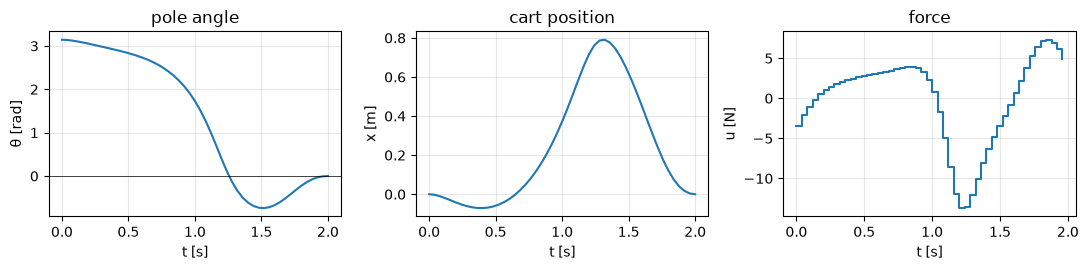

In [13]:
mc, mp, L, g_ = 1.0, 0.2, 0.5, 9.81

def cartpole(s, u):
    th, dx, dth = s[1], s[2], s[3]
    sth, cth = ca.sin(th), ca.cos(th)
    den = mc + mp * sth**2
    return ca.vertcat(
        dx,
        dth,
        (u + mp * sth * (L * dth**2 + g_ * cth)) / den,
        (-u * cth - mp * L * dth**2 * cth * sth - (mc + mp) * g_ * sth) / (L * den),
    )

def rk4(s, u, h):
    k1 = cartpole(s, u); k2 = cartpole(s + h/2*k1, u)
    k3 = cartpole(s + h/2*k2, u); k4 = cartpole(s + h*k3, u)
    return s + h/6 * (k1 + 2*k2 + 2*k3 + k4)

Nsw, Tsw = 50, 2.0

def build_swingup():
    h = Tsw / Nsw
    opti = ca.Opti()
    S, U = opti.variable(4, Nsw + 1), opti.variable(1, Nsw)
    for k in range(Nsw):
        opti.subject_to(S[:, k+1] == rk4(S[:, k], U[0, k], h))
    opti.subject_to(S[:, 0] == ca.DM([0, np.pi, 0, 0]))     # hanging down, at rest
    opti.subject_to(S[:, Nsw] == ca.DM([0, 0, 0, 0]))       # upright, at rest
    opti.subject_to(opti.bounded(-20, U, 20))               # force limit
    opti.subject_to(opti.bounded(-2, S[0, :], 2))           # track length
    opti.minimize(h * ca.sumsqr(U))
    opti.set_initial(S[1, :], np.linspace(np.pi, 0, Nsw + 1))   # rotate the pole up
    return {"opti": opti, "S": S, "U": U, "h": h}

def solve_swingup(plugin):
    # A fresh Opti per solver: opti.solve() leaves its solution behind as the
    # next call's initial guess, so re-solving the same object would hand the
    # second solver the first one's answer.
    o = build_swingup()
    o["opti"].solver(plugin, {"print_time": False}, {"print_level": 0})
    t0 = time.perf_counter()
    sol = o["opti"].solve()
    return sol, o, (time.perf_counter() - t0) * 1e3

for plugin in ("pounce", "ipopt"):
    sw, o, ms = solve_swingup(plugin)
    print(f"{plugin:7s} {sw.stats()['return_status']:16s} "
          f"iters={sw.stats()['iter_count']:3d} "
          f"effort={float(sw.value(o['h']*ca.sumsqr(o['U']))):8.4f} "
          f"{ms:8.1f} ms")
sw_pounce, o_p, _ = solve_swingup("pounce")   # trajectory to plot

ts = np.arange(Nsw + 1) * o_p["h"]
fig, ax = plt.subplots(1, 3, figsize=(11, 2.8))
ax[0].plot(ts, sw_pounce.value(o_p["S"][1, :])); ax[0].set(xlabel="t [s]", ylabel="θ [rad]", title="pole angle")
ax[0].axhline(0, color="k", lw=0.5)
ax[1].plot(ts, sw_pounce.value(o_p["S"][0, :])); ax[1].set(xlabel="t [s]", ylabel="x [m]", title="cart position")
ax[2].step(ts[:-1], sw_pounce.value(o_p["U"]), where="post"); ax[2].set(xlabel="t [s]", ylabel="u [N]", title="force")
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()

**Part two: balancing, against a control deadline.** The pole is up but
disturbed by 0.35 rad. A 25-step horizon at 40 ms — 25 Hz — is re-solved every
step from the measured state, which is the parameter. This is where warm
starting stops being a nicety: the question is not "how fast is the solver on
average" but "does *every* step finish inside the period", so the number that
sizes the loop is the **max**, not the mean.

    rate   period           mean     max   deadline


     25Hz     40ms   cold    21.9    28.6   fits
     25Hz     40ms   warm    16.1    19.2   fits


     50Hz     20ms   cold    24.1    39.9   MISSES
     50Hz     20ms   warm    16.6    25.4   MISSES

θ driven from 0.35 rad to -0.0209 rad in 40 steps


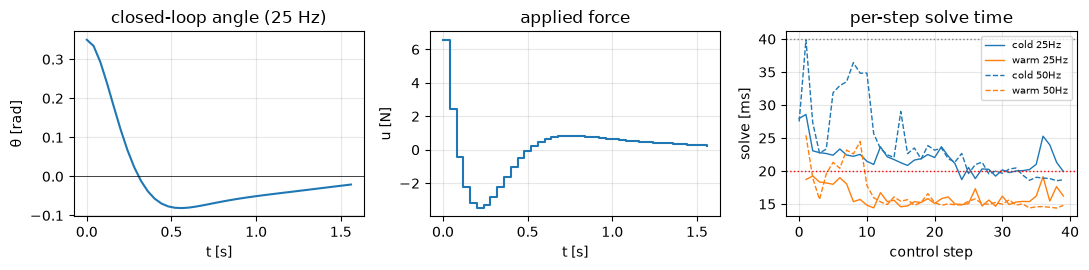

In [14]:
Nm = 25                                   # horizon steps

def build_mpc(hm):
    Sm, Um = ca.MX.sym("S", 4, Nm + 1), ca.MX.sym("U", 1, Nm)
    s0p = ca.MX.sym("s0p", 4)
    cost, cons = 0, [Sm[:, 0] - s0p]
    for k in range(Nm):
        cons.append(Sm[:, k+1] - rk4(Sm[:, k], Um[0, k], hm))
        cost += (10*Sm[1, k]**2 + Sm[0, k]**2
                 + 0.1*(Sm[2, k]**2 + Sm[3, k]**2) + 0.01*Um[0, k]**2)
    cost += 100 * (Sm[1, Nm]**2 + Sm[3, Nm]**2)
    nlp = {"x": ca.vertcat(ca.vec(Sm), ca.vec(Um)), "p": s0p,
           "f": cost, "g": ca.vertcat(*cons)}
    args = dict(lbg=0, ubg=0,
                lbx=[-ca.inf] * (4 * (Nm + 1)) + [-20.0] * Nm,
                ubx=[ca.inf] * (4 * (Nm + 1)) + [20.0] * Nm)
    return nlp, 4 * (Nm + 1) + Nm, args

def closed_loop(hm, steps=40):
    nlp_m, nxc, cargs = build_mpc(hm)
    base = {"print_level": 0, "tol": 1e-6}
    cold = ca.nlpsol("cold_cp", "pounce", nlp_m, {"print_time": False, "pounce": base})
    warm = ca.nlpsol("warm_cp", "pounce", nlp_m, {"print_time": False, "pounce": dict(
        base, warm_start_init_point="yes", mu_init=1e-6)})
    state, prev = ca.DM([0.0, 0.35, 0.0, 0.0]), None
    t_cold, t_warm, traj = [], [], []
    for step in range(steps):
        t0 = time.perf_counter()                  # what a cold solve would cost
        cold(x0=ca.DM.zeros(nxc), p=state, **cargs)
        t_cold.append((time.perf_counter() - t0) * 1e3)

        t0 = time.perf_counter()                  # what the loop actually runs
        if prev is None:
            prev = cold(x0=ca.DM.zeros(nxc), p=state, **cargs)
        else:
            prev = warm(x0=prev["x"], lam_g0=prev["lam_g"], lam_x0=prev["lam_x"],
                        p=state, **cargs)
            t_warm.append((time.perf_counter() - t0) * 1e3)

        u0 = float(prev["x"][4 * (Nm + 1)])
        traj.append((float(state[1]), u0))
        state = ca.DM(np.array(rk4(state, u0, hm)).ravel())
    return np.array(t_cold), np.array(t_warm), traj

runs = {}
print(f"{'rate':>8s} {'period':>8s} {'':>6s}{'mean':>8s}{'max':>8s}   deadline")
for hm in (0.04, 0.02):                          # 25 Hz, then 50 Hz
    tc, tw, traj = closed_loop(hm)
    runs[hm] = (tc, tw, traj)
    for label, arr in (("cold", tc), ("warm", tw)):
        verdict = "fits" if arr.max() < hm * 1e3 else "MISSES"
        print(f"{1/hm:7.0f}Hz {hm*1e3:6.0f}ms {label:>6s}{arr.mean():8.1f}{arr.max():8.1f}   {verdict}")

tc, tw, traj = runs[0.04]
th, uu = zip(*traj)
tt = np.arange(len(traj)) * 0.04
fig, ax = plt.subplots(1, 3, figsize=(11, 2.8))
ax[0].plot(tt, th); ax[0].axhline(0, color="k", lw=0.5)
ax[0].set(xlabel="t [s]", ylabel="θ [rad]", title="closed-loop angle (25 Hz)")
ax[1].step(tt, uu, where="post"); ax[1].set(xlabel="t [s]", ylabel="u [N]", title="applied force")
for hm, style in ((0.04, "-"), (0.02, "--")):
    c, w, _ = runs[hm]
    ax[2].plot(c, style, color="C0", lw=1, label=f"cold {1/hm:.0f}Hz")
    ax[2].plot(np.arange(1, len(w) + 1), w, style, color="C1", lw=1, label=f"warm {1/hm:.0f}Hz")
for hm, col in ((0.04, "0.5"), (0.02, "r")):
    ax[2].axhline(hm * 1e3, color=col, ls=":", lw=1)
ax[2].set(xlabel="control step", ylabel="solve [ms]", title="per-step solve time")
ax[2].legend(fontsize=7)
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()
print(f"\nθ driven from 0.35 rad to {traj[-1][0]:+.4f} rad in {len(traj)} steps")

The table is the point, and it is more interesting than "warm start is faster".
Read the `deadline` column first. At 25 Hz both loops fit, but the margins are
not comparable — the warm worst case sits around 19 ms against the cold 29 ms,
and margin is what absorbs a slow step. At 50 Hz neither fits this horizon on
this machine, warm starting included: it moves the mean a long way and the
worst step much less, and the worst step is what sizes a real-time loop. Which
is why the honest answer to "can POUNCE run my controller at *N* Hz" is always
"measure it, on your horizon and your hardware".

When a horizon does not fit, the levers are the usual ones: shorten it, coarsen
the discretization, take a real-time-iteration approach (one SQP step per
period — `algorithm=active-set-sqp` with `max_iter=1` is the crude version), or
accept the slower rate. `stats()["iterations"]` tells you which steps were
expensive and why, and `iteration_callback` can abort a step that overruns.

Everything else in this notebook composes onto this problem: the section-5
feedback gain is `jacobian(u0, s0p)` here — the local linear controller around
the trajectory, and the one place where the `clip_inactive_lam` default earns
its keep, because the force bounds make every control a bounded variable.

## Where to go next

- [`docs/src/casadi.md`](../../docs/src/casadi.md) — the full integration
  reference: options, build and ABI constraints, what is not supported.
- [`casadi/examples/`](https://github.com/jkitchin/pounce/tree/main/casadi/examples)
  — the six scripts these sections are drawn from, runnable with
  `make -C casadi examples`.
- `make -C casadi test` — 18 parity checks against CasADi's bundled Ipopt.
- POUNCE has machinery the plugin does not expose yet: its own
  [parametric sensitivity](../../docs/src/sensitivity.md) and
  [active-set SQP warm starts](../../docs/src/active-set-sqp-warm-start.md).
  If you want those from CasADi, say so on the issue tracker.